# Chemistry-state purity amplification: which $N$ and $T$ are compatible with a given $k$?

**Follow-up resource estimate for the cyclic QPA of [arXiv:2409.18167](https://arxiv.org/abs/2409.18167) — answering Mario's second round of questions.**

Mario proposed concrete chemistry targets for $\rho$ and, crucially, gave the **two-qubit
gate cost to *prepare* $\rho$** for each subsystem size:

| $k$ (qubits in $\rho$) | example $\rho$ | 2Q gates to prepare $\rho$ |
|---|---|---|
| 2 | 2-spin state, or a (2e,2o) active space under parity + 2-qubit reduction (SQD or VQE; not LUCJ) | (~3, extrapolated) |
| 4 | small active space | 13 |
| 6 | | 29 |
| 8 | | 51 |
| 10 | | 80 |
| 12 | | 115 |

> *Mario's question:* "Do you think there would be values of $N$ and $T$ that are interesting
> (for purity amplification) and compatible with those values of $k$?"

This notebook adds the **state-preparation cost** — absent from the first resource estimate, which
treated $\rho$ as given — and sweeps $(N, T)$ for each chemistry $k$ to find the compatible window.

## What "compatible" means once you must *prepare* $\rho$

The first notebook (`transpile_scaling_purity_amplification.ipynb`) costed only the amplification
machinery and treated each copy of $\rho$ as free. For a real chemistry demo we must prepare **$N$
independent copies** of $\rho$, so a second cost term appears that the amplifier itself does not
control. Three constraints now decide whether an $(N, T)$ is "compatible":

1. **Qubit budget.** $N$ copies of $k$ qubits plus $(N-1)/2$ swap-test ancillas:
   $\;n_\text{qubits} = N k + (N-1)/2 \le 156$ (one Heron r2 device).
2. **Gate count & depth (noise).** Total two-qubit gates split into a **state-prep** term and an
   **amplification** term:
   $$ N_{2Q}^{\text{(ideal)}} \;=\; \underbrace{N\cdot c_\text{prep}(k)}_{\text{prepare }N\text{ copies}}
      \;+\; \underbrace{3.5\,k\,T\,(N-1)}_{\text{Fredkin swap tests}}, $$
   times a heavy-hex routing multiplier ($\sim2$–$3\times$). For large $k$ the **prep term dominates**
   and scales as $N k^2$.
3. **Post-selection cost.** The longest (all-pass) path requires all $S = T\,(N-1)/2$ swap tests to
   accept; the shot budget grows like $1/p_\text{acc}$, and $p_\text{acc}\approx\big(\tfrac{1+P}{2}\big)^{S}$
   for a state of purity $P$. Large $N$ *and* large $T$ both inflate this.

### The two amplifier knobs (recap)
* **$T$ (rounds)** — sequential amplification of the *reserve* register. Adds depth and gates
  **linearly** and **adds no qubits and no extra copies to prepare**. The cheap knob.
* **$N$ (copies, odd)** — parallel breadth: more copies symmetrized per round. Raises the qubit
  count *and* multiplies the state-prep cost by $N$. The expensive knob for chemistry.

The minimal $m=2$ demonstration is a single swap test: $N=3,\,T=1$.

In [1]:
# === repo-root bootstrap ===
import os, sys
os.environ["QISKIT_PARALLEL"] = "FALSE"   # avoid spawn-deadlock under nbconvert on macOS
_root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_root, "core")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
assert os.path.isdir(os.path.join(_root, "core")), "repo root (with core/) not found"
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Repo root:", _root)

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh
import qiskit
print("qiskit", qiskit.__version__)

OUTDIR = os.path.join("shared_data", "experiment_results", "scaling")
os.makedirs(OUTDIR, exist_ok=True)
print("Outputs ->", OUTDIR)

Repo root: /Users/henryzou/Documents/GitHub/OQPA


qiskit 2.3.0
Outputs -> shared_data/experiment_results/scaling


## The state-preparation model

Mario's reported costs follow a clean quadratic, $c_\text{prep}(k)\approx 0.8\,k^2$ — essentially
exact for $k=4\ldots12$ (and a reasonable $\sim3$ for the $k=2$ parity-encoded case). This is the
expected scaling for a generic (e.g. Givens-rotation / hardware-efficient) state-prep on $k$ qubits.

For the resource estimate we only need each copy's **two-qubit footprint** to be faithful, not the
specific state. `prep_block` lays down a hardware-efficient brickwork with exactly $c_\text{prep}(k)$
CX gates — a stand-in whose transpiled cost matches a real chemistry preparation.

In [2]:
def prep_2q(k):
    '''Two-qubit gates to prepare one copy of rho (Mario's chemistry numbers, ~0.8 k^2).'''
    EXACT = {2: 3, 4: 13, 6: 29, 8: 51, 10: 80, 12: 115}   # k=2 extrapolated
    return EXACT.get(k, max(1, round(0.8 * k * k)))

def prep_block(qc, qubits, target_2q, seed=0):
    '''Hardware-efficient brickwork with exactly `target_2q` CX gates.

    A faithful 2Q-footprint stand-in for a chemistry state-prep (the specific
    angles are irrelevant to a gate-count / depth resource estimate).'''
    rng = np.random.default_rng(seed)
    k = len(qubits)
    for q in qubits:
        qc.ry(rng.uniform(0, 2 * np.pi), q)
    placed, layer = 0, 0
    while placed < target_2q and k > 1:
        for i in range(layer % 2, k - 1, 2):
            if placed >= target_2q:
                break
            qc.cx(qubits[i], qubits[i + 1]); placed += 1
            qc.ry(rng.uniform(0, 2 * np.pi), qubits[i + 1])
        layer += 1
    return placed

print("k : c_prep(k)  vs  0.8 k^2")
for k in (2, 4, 6, 8, 10, 12):
    print(f"  {k:2d} : {prep_2q(k):4d}      {0.8*k*k:6.1f}")

k : c_prep(k)  vs  0.8 k^2
   2 :    3         3.2
   4 :   13        12.8
   6 :   29        28.8
   8 :   51        51.2
  10 :   80        80.0
  12 :  115       115.2


## The full circuit = prepare $N$ copies + cyclic-QPA longest path

`build_full_qpa(k, N, T)` first prepares each of the $N$ data registers with `prep_block`, then
appends the **longest-path** (all-swap-tests-pass) amplifier — identical to
`build_qpa` in the first notebook / `UnrolledStrategy.build_longest_path` in
`../dynamic_transpilation/qpa_engine.py`. Each round runs $(N-1)/2$ parallel Schur tests
($H\cdot\text{CSWAP}^k\cdot H$) on a reused ancilla pool, then cyclically rotates all $N$
registers; the reserve register is measured at the end.

In [3]:
def build_full_qpa(k, N, T, with_prep=True):
    '''Prepare N copies of rho (chemistry state-prep) then run the longest-path cyclic QPA.'''
    assert N % 2 == 1, "N must be odd (2i+1)"
    data = [QuantumRegister(k, f"R{i+1}") for i in range(N)]
    n_pairs = (N - 1) // 2
    anc = QuantumRegister(n_pairs, "anc")                 # reused pool (reset each round)
    cr_anc = ClassicalRegister(T * n_pairs, "schur")
    cr_out = ClassicalRegister(k, "readout")
    qc = QuantumCircuit(*data, anc, cr_anc, cr_out)

    if with_prep:                                          # <-- new: prepare each copy of rho
        c = prep_2q(k)
        for i, reg in enumerate(data):
            prep_block(qc, [reg[b] for b in range(k)], c, seed=i)
        qc.barrier()

    m = 0
    for t in range(T):
        for i in range(n_pairs):                           # controlled-P = CSWAP^k swap tests
            a, ra, rb = anc[i], data[2 * i], data[2 * i + 1]
            qc.h(a)
            for b in range(k):
                qc.cswap(a, ra[b], rb[b])
            qc.h(a)
            qc.measure(a, cr_anc[m]); m += 1
            qc.reset(a)
        for b in range(k):                                 # uncontrolled P = cyclic rotation
            for j in range(N - 1, 0, -1):
                qc.swap(data[j][b], data[j - 1][b])
    qc.measure(data[-1], cr_out)                           # keep the purified reserve
    return qc

def logical_counts(k, N, T):
    n_pairs = (N - 1) // 2
    prep = N * prep_2q(k)
    fredkin = 7 * k * T * n_pairs            # 7 two-qubit gates per CSWAP
    return dict(
        total_qubits = N * k + n_pairs,
        prep_2q      = prep,
        ampl_2q      = fredkin,              # routing-free (SWAPs elided all-to-all)
        ideal_2q     = prep + fredkin,
        swap_tests   = T * n_pairs,
    )

print("k=4 (2e,2o-ish), N=3, T=1:", logical_counts(4, 3, 1))

k=4 (2e,2o-ish), N=3, T=1: {'total_qubits': 13, 'prep_2q': 39, 'ampl_2q': 28, 'ideal_2q': 67, 'swap_tests': 1}


## Transpilation helpers

Same two-backend treatment as the first notebook: an **all-to-all** lower bound (the `ibm_boston`
basis, where the cyclic-rotation SWAPs are elided by virtual relabeling so only state-prep CX +
Fredkin survive) and a realistic **heavy-hex device** (`FakeMarrakesh`, a 156-qubit Heron r2
snapshot standing in for `ibm_pittsburgh`) with routing, best of a few seeds by depth.

In [4]:
BOSTON_BASIS = ["cz", "rz", "sx", "x", "id"]
pm_basis = generate_preset_pass_manager(optimization_level=3, basis_gates=BOSTON_BASIS,
                                        seed_transpiler=1)

N_SEEDS = 4
DEVICE = FakeMarrakesh()
pm_device_seeds = [generate_preset_pass_manager(optimization_level=3, backend=DEVICE,
                                                 seed_transpiler=s) for s in range(N_SEEDS)]
print("Device:", DEVICE.name, "|", DEVICE.num_qubits, "qubits")

TWO_Q = {"ecr", "cz", "cx"}

def two_q_depth(circ):
    """Circuit depth counting only two-qubit gates (the noise-relevant depth)."""
    return circ.depth(filter_function=lambda instr: len(instr.qubits) == 2)

def _summarize(qc, t):
    ops = t.count_ops()
    total = sum(v for g, v in ops.items() if g not in ("measure", "barrier", "reset"))
    twoq = sum(v for g, v in ops.items() if g in TWO_Q)
    return dict(qubits=qc.num_qubits, depth=t.depth(), two_q_depth=two_q_depth(t),
                total_gates=total, two_q_gates=twoq)

def measure(k, N, T, mode="device"):
    qc = build_full_qpa(k, N, T)
    if mode == "device":
        if qc.num_qubits > DEVICE.num_qubits:
            return None
        best = min((pm.run(qc) for pm in pm_device_seeds), key=lambda t: two_q_depth(t))
        return dict(k=k, N=N, T=T, mode=mode, **_summarize(qc, best))
    return dict(k=k, N=N, T=T, mode=mode, **_summarize(qc, pm_basis.run(qc)))

print("k=4, N=3, T=1  device  :", measure(4, 3, 1, "device"))
print("k=4, N=3, T=1  all2all :", measure(4, 3, 1, "basis"))

Device: fake_marrakesh | 156 qubits
k=4, N=3, T=1  device  : {'k': 4, 'N': 3, 'T': 1, 'mode': 'device', 'qubits': 13, 'depth': 182, 'two_q_depth': 49, 'total_gates': 539, 'two_q_gates': 94}
k=4, N=3, T=1  all2all : {'k': 4, 'N': 3, 'T': 1, 'mode': 'basis', 'qubits': 13, 'depth': 118, 'two_q_depth': 31, 'total_gates': 417, 'two_q_gates': 67}


## Post-selection / shot model

The longest path keeps shots only when **all** $S = T(N-1)/2$ swap tests pass. For a state of
purity $P=\mathrm{Tr}\,\rho^2$ each test accepts with $p=(1+P)/2$, so the all-pass acceptance is
$\approx p^{S}$ and the shot multiplier is its inverse. (This is a conservative reading — purity
rises across rounds, raising later $p$ — but it captures how $N$ and $T$ jointly inflate the shot
budget.)

In [5]:
def acceptance(N, T, P=0.6):
    S = T * (N - 1) // 2
    return ((1 + P) / 2) ** S, S

for (N, T) in [(3, 1), (3, 3), (5, 1), (5, 3), (7, 3)]:
    a, S = acceptance(N, T, P=0.6)
    print(f"N={N} T={T}: swap-tests={S:2d}  acceptance(P=0.6)={a:6.3f}  ->  ~{1/a:6.1f}x shots")

N=3 T=1: swap-tests= 1  acceptance(P=0.6)= 0.800  ->  ~   1.2x shots
N=3 T=3: swap-tests= 3  acceptance(P=0.6)= 0.512  ->  ~   2.0x shots
N=5 T=1: swap-tests= 2  acceptance(P=0.6)= 0.640  ->  ~   1.6x shots
N=5 T=3: swap-tests= 6  acceptance(P=0.6)= 0.262  ->  ~   3.8x shots
N=7 T=3: swap-tests= 9  acceptance(P=0.6)= 0.134  ->  ~   7.5x shots


## The main result — $(N, T)$ grid for each chemistry $k$

For every chemistry target we sweep $N\in\{3,5,7\}$ (odd) and $T\in\{1,2,3\}$ and report qubits,
ideal/device two-qubit gates, device **two-qubit depth**, and the post-selection shot multiplier. A
cell is flagged **feasible** when it fits 156 qubits, stays under a soft device budget (≲3000
two-qubit gates, **2Q-depth ≲400** — already optimistic for 2026), and keeps the shot multiplier
modest (≲20×).

In [6]:
CHEM_K   = [2, 4, 6, 8, 10, 12]
N_GRID   = [3, 5, 7]
T_GRID   = [1, 2, 3]
P_TYPICAL = 0.6                     # representative NISQ chemistry-state purity

BUDGET_2Q, BUDGET_2QDEPTH, BUDGET_SHOTS = 3000, 400, 20

def feasible(row):
    return (row["qubits"] <= DEVICE.num_qubits and row["dev_2q"] is not None
            and row["dev_2q"] <= BUDGET_2Q and row["twoq_depth"] <= BUDGET_2QDEPTH
            and row["shot_mult"] <= BUDGET_SHOTS)

grid = {}
for k in CHEM_K:
    for N in N_GRID:
        for T in T_GRID:
            lc = logical_counts(k, N, T)
            d = measure(k, N, T, "device")
            a, S = acceptance(N, T, P_TYPICAL)
            row = dict(k=k, N=N, T=T, qubits=lc["total_qubits"],
                       prep_2q=lc["prep_2q"], ideal_2q=lc["ideal_2q"],
                       dev_2q=(None if d is None else d["two_q_gates"]),
                       twoq_depth=(None if d is None else d["two_q_depth"]),
                       shot_mult=round(1 / a, 1))
            row["feasible"] = feasible(row)
            grid[(k, N, T)] = row

for k in CHEM_K:
    ex = "2-spin / (2e,2o) parity" if k == 2 else "active space"
    print(f"\n=== k = {k}  (prepare 1 copy = {prep_2q(k)} 2Q;  rho: {ex}) ===")
    print(f"  {'N':>2} {'T':>2} {'qubits':>7} {'prep2Q':>7} {'ideal2Q':>8} "
          f"{'dev2Q':>7} {'2Qdep':>6} {'shots':>7}  feasible")
    for N in N_GRID:
        for T in T_GRID:
            r = grid[(k, N, T)]
            dev = "      —" if r["dev_2q"] is None else f"{r['dev_2q']:7d}"
            dep = "     —" if r["twoq_depth"] is None else f"{r['twoq_depth']:6d}"
            flag = "  <== YES" if r["feasible"] else ""
            print(f"  {N:>2} {T:>2} {r['qubits']:>7} {r['prep_2q']:>7} {r['ideal_2q']:>8} "
                  f"{dev} {dep} {r['shot_mult']:>7}{flag}")


=== k = 2  (prepare 1 copy = 3 2Q;  rho: 2-spin / (2e,2o) parity) ===
   N  T  qubits  prep2Q  ideal2Q   dev2Q  2Qdep   shots  feasible
   3  1       7       9       23      30     24     1.2  <== YES
   3  2       7       9       37      59     47     1.6  <== YES
   3  3       7       9       51      84     65     2.0  <== YES
   5  1      12      15       43      59     24     1.6  <== YES
   5  2      12      15       71     120     48     2.4  <== YES
   5  3      12      15       99     174     69     3.8  <== YES
   7  1      17      21       63      90     29     2.0  <== YES
   7  2      17      21      105     191     54     3.8  <== YES
   7  3      17      21      147     310     99     7.5  <== YES

=== k = 4  (prepare 1 copy = 13 2Q;  rho: active space) ===
   N  T  qubits  prep2Q  ideal2Q   dev2Q  2Qdep   shots  feasible
   3  1      13      39       67      94     49     1.2  <== YES
   3  2      13      39       95     170     96     1.6  <== YES
   3  3      13      

## How the budget splits: state-prep vs. amplification

The plot shows, for each $k$ at the minimal $N=3,\,T=1$, how the ideal two-qubit budget divides
between **preparing the copies** ($N\,c_\text{prep}\sim N k^2$) and the **amplifier** ($3.5kT(N-1)$).
Past $k\approx6$ the chemistry state-prep is the dominant cost — so for large $k$ the amplifier is
"free" and the real question is how many copies $N$ you can afford to prepare.

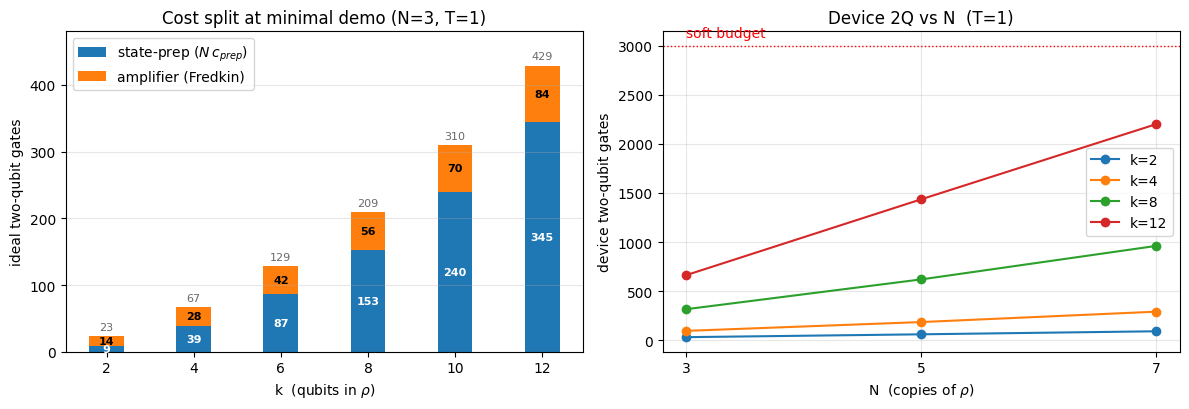

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

prep = [logical_counts(k, 3, 1)["prep_2q"] for k in CHEM_K]
ampl = [logical_counts(k, 3, 1)["ampl_2q"] for k in CHEM_K]
b_prep = ax[0].bar(CHEM_K, prep, label="state-prep ($N\\,c_{prep}$)", color="C0")
b_ampl = ax[0].bar(CHEM_K, ampl, bottom=prep, label="amplifier (Fredkin)", color="C1")
# exact value of each segment, centered in its part of the bar ...
ax[0].bar_label(b_prep, label_type="center", color="white", fontsize=8, fontweight="bold")
ax[0].bar_label(b_ampl, label_type="center", color="black", fontsize=8, fontweight="bold")
# ... and the stacked total above each bar
ax[0].bar_label(b_ampl, labels=[f"{p + a}" for p, a in zip(prep, ampl)],
                padding=3, fontsize=8, color="dimgray")
ax[0].margins(y=0.12)
ax[0].set_xlabel("k  (qubits in $\\rho$)"); ax[0].set_ylabel("ideal two-qubit gates")
ax[0].set_title("Cost split at minimal demo (N=3, T=1)"); ax[0].legend(); ax[0].grid(alpha=.3, axis="y")

for k, c in zip([2, 4, 8, 12], ["C0", "C1", "C2", "C3"]):
    ys = [grid[(k, N, 1)]["dev_2q"] for N in N_GRID]
    ax[1].plot(N_GRID, ys, "o-", color=c, label=f"k={k}")
ax[1].axhline(BUDGET_2Q, color="r", ls=":", lw=1); ax[1].text(3, BUDGET_2Q*1.03, "soft budget", color="r")
ax[1].set_xlabel("N  (copies of $\\rho$)"); ax[1].set_ylabel("device two-qubit gates")
ax[1].set_title("Device 2Q vs N  (T=1)"); ax[1].set_xticks(N_GRID); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "chem_cost_split.png"), dpi=130); plt.show()

## Recommended $(N, T)$ per chemistry target

For each $k$, pick the most aggressive feasible amplification, **ranking by $T$ first**: rounds are
the knob that sequentially amplifies the kept *reserve* register (and they add no qubits / no extra
copies to prepare), so they are the primary driver of purity gain. $N$ (the pool of fresh copies
feeding each round) is the tie-breaker, used only while prep cost and post-selection allow.

In [8]:
def recommend(k):
    cands = [grid[(k, N, T)] for N in N_GRID for T in T_GRID if grid[(k, N, T)]["feasible"]]
    if not cands:
        return None
    # rank by rounds T first (the reserve-amplification knob), then by pool size N
    cands.sort(key=lambda r: (r["T"], r["N"]), reverse=True)
    return cands[0]

print(f"{'k':>2}  {'rho example':<34} {'rec(N,T)':>9} {'qubits':>7} {'dev2Q':>7} {'2Qdep':>6} {'shots':>6}")
for k in CHEM_K:
    r = recommend(k)
    ex = "2-spin / (2e,2o) parity (SQD/VQE)" if k == 2 else f"{k}-qubit active space (SQD/VQE)"
    if r is None:
        print(f"{k:>2}  {ex:<34} {'none*':>9}   (* even N=3,T=1 exceeds the soft budget)")
    else:
        nt = f"({r['N']},{r['T']})"
        print(f"{k:>2}  {ex:<34} {nt:>9} {r['qubits']:>7} {r['dev_2q']:>7} {r['twoq_depth']:>6} {r['shot_mult']:>6}")

 k  rho example                         rec(N,T)  qubits   dev2Q  2Qdep  shots
 2  2-spin / (2e,2o) parity (SQD/VQE)      (7,3)      17     310     99    7.5
 4  4-qubit active space (SQD/VQE)         (7,3)      31     868    245    7.5
 6  6-qubit active space (SQD/VQE)         (7,3)      45    1751    400    7.5
 8  8-qubit active space (SQD/VQE)         (3,3)      25     760    384    2.0
10  10-qubit active space (SQD/VQE)        (5,2)      52    1749    376    2.4
12  12-qubit active space (SQD/VQE)        (7,1)      87    2203    295    2.0


## Answer for Mario

**Short version: yes — there is an interesting, compatible window, but it shrinks as $k$ grows, and
for the larger active spaces the binding constraint becomes *preparing the copies*, not the
amplifier.**

* **State-prep is the new dominant cost.** $c_\text{prep}(k)\approx0.8\,k^2$ (your numbers, almost
  exactly), and we need $N$ copies, so the prep term $N\cdot0.8k^2$ overtakes the amplifier's
  $3.5kT(N-1)$ around $k\approx6$. Past that, the amplifier is essentially free and the question is
  purely *how many copies can we afford to prepare and route*.
* **$T$ is the knob to lean on.** Extra rounds amplify the reserve sequentially, add gates/depth only
  linearly, and cost **no extra qubits and no extra copies** — so for every $k$ the cheapest way to go
  beyond the minimal $m=2$ demo is to raise $T$, not $N$.
* **$N$ is gated by prep + post-selection, not by qubits.** Even $k=12$ fits many copies in 156
  qubits ($N=11\Rightarrow137$ qubits), but each added pair multiplies state-prep and drops the
  all-pass acceptance by $\sim(\tfrac{1+P}{2})$ per swap test, inflating shots.
* **Where the wall is, by $k$** (recommendation table above): the smaller targets ($k=2,4$) comfortably
  reach **3 rounds with a 7-copy pool** ($N=7,T=3$); $k=6$ supports $T=3$ at $N=3$ and $T=2$ wider;
  $k=8$ tops out around $N=5,T=2$; and the largest ($k=10,12$) hit the **depth** wall after a single
  round, so within a credible 2026 budget they are realistically $T=1$ demos (a wider $N$ pool is the
  only remaining lever). Genuine multi-round amplification at $k\ge10$ needs error rates past 2026.

**One honest caveat to flag.** This notebook pins down the *resource* side exactly (qubits, gates,
depth, shots). What it does **not** yet quantify is the *amplification* side — the precise map from
$(N,T)$ to an effective amplification order $m_\text{eff}$ and the purity actually delivered for a
given input purity. That is the natural next step, and we already have the noisy-simulation tooling
in the repo (`core/`, `experiments/dynamic_transpilation/qpa_engine.py`) to measure $m_\text{eff}(N,T)$
directly and confirm which feasible cells give a worthwhile purity gain. The headline from the first
estimate still holds: a compact $m=2$ demonstration ($N=3,T=1$) is in reach, and for the smaller
chemistry targets we can push to genuinely higher-order, multi-round amplification.